Прежде чем вообще рассказывать про svm, я вынужден рассказать немного про bias, variance и пару важных вещей, непосредственно связанных с ними. Они принципиально важны для svm, и, на самом деле, при изучении других алгоритмов мл, от логрега до каких-нибудь visual transformers

Так вот  
Bias(смещение, предвзятость) - неспособность модели предсказывать истинную взаимосвязь, ошибка неверных предположений во время обучения.
Variance(разброс, дисперсия) - ошибка модели, вызванная слишкком большой чувствительностью к шуму.  

Высокий bias ассоциирован с недообучением(underfitting) - то есть с таким негативным явлением, когда алгоритм не обеспечивает достаточно малой величины средней ошибки на обучающей выборке. Недообучение может также возникнуть при использовании недостаточно сложных моделей  
Высокий variance ассоциирован с переобучением(overfitting) - то есть с таким негативным явлением, когда алгоритм вырабатывает слишком точные предсказания для обучающей выборки, от чего предсказания на тестовой выборке становятся менее точными

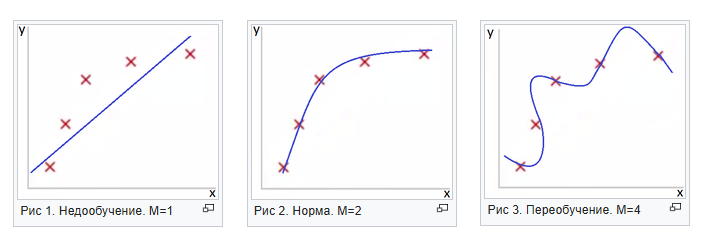  
(картинку взял из https://neerc.ifmo.ru/wiki/index.php?title=%D0%9F%D0%B5%D1%80%D0%B5%D0%BE%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5)

Во всём машинном обучении есть дилемма bias-variance, то есть конфликт в попытке минимизировать и bias, и variance. 

Теперь переходим к методу опорных векторов(SVM - support vector machine)  
Используя этот метод, мы ищем такую гиперплоскость, чтобы она  
а) правильно разделяла объекты на классы  
б) чтобы был некоторый зазор, свободное место между ближайшими точками из классов и гиперплоскостью, то есть был margin  
Ближайшие к гиперплоскости объекты называются опорными векторами (support vectors). Именно они определяют положение оптимальной гиперплоскости.

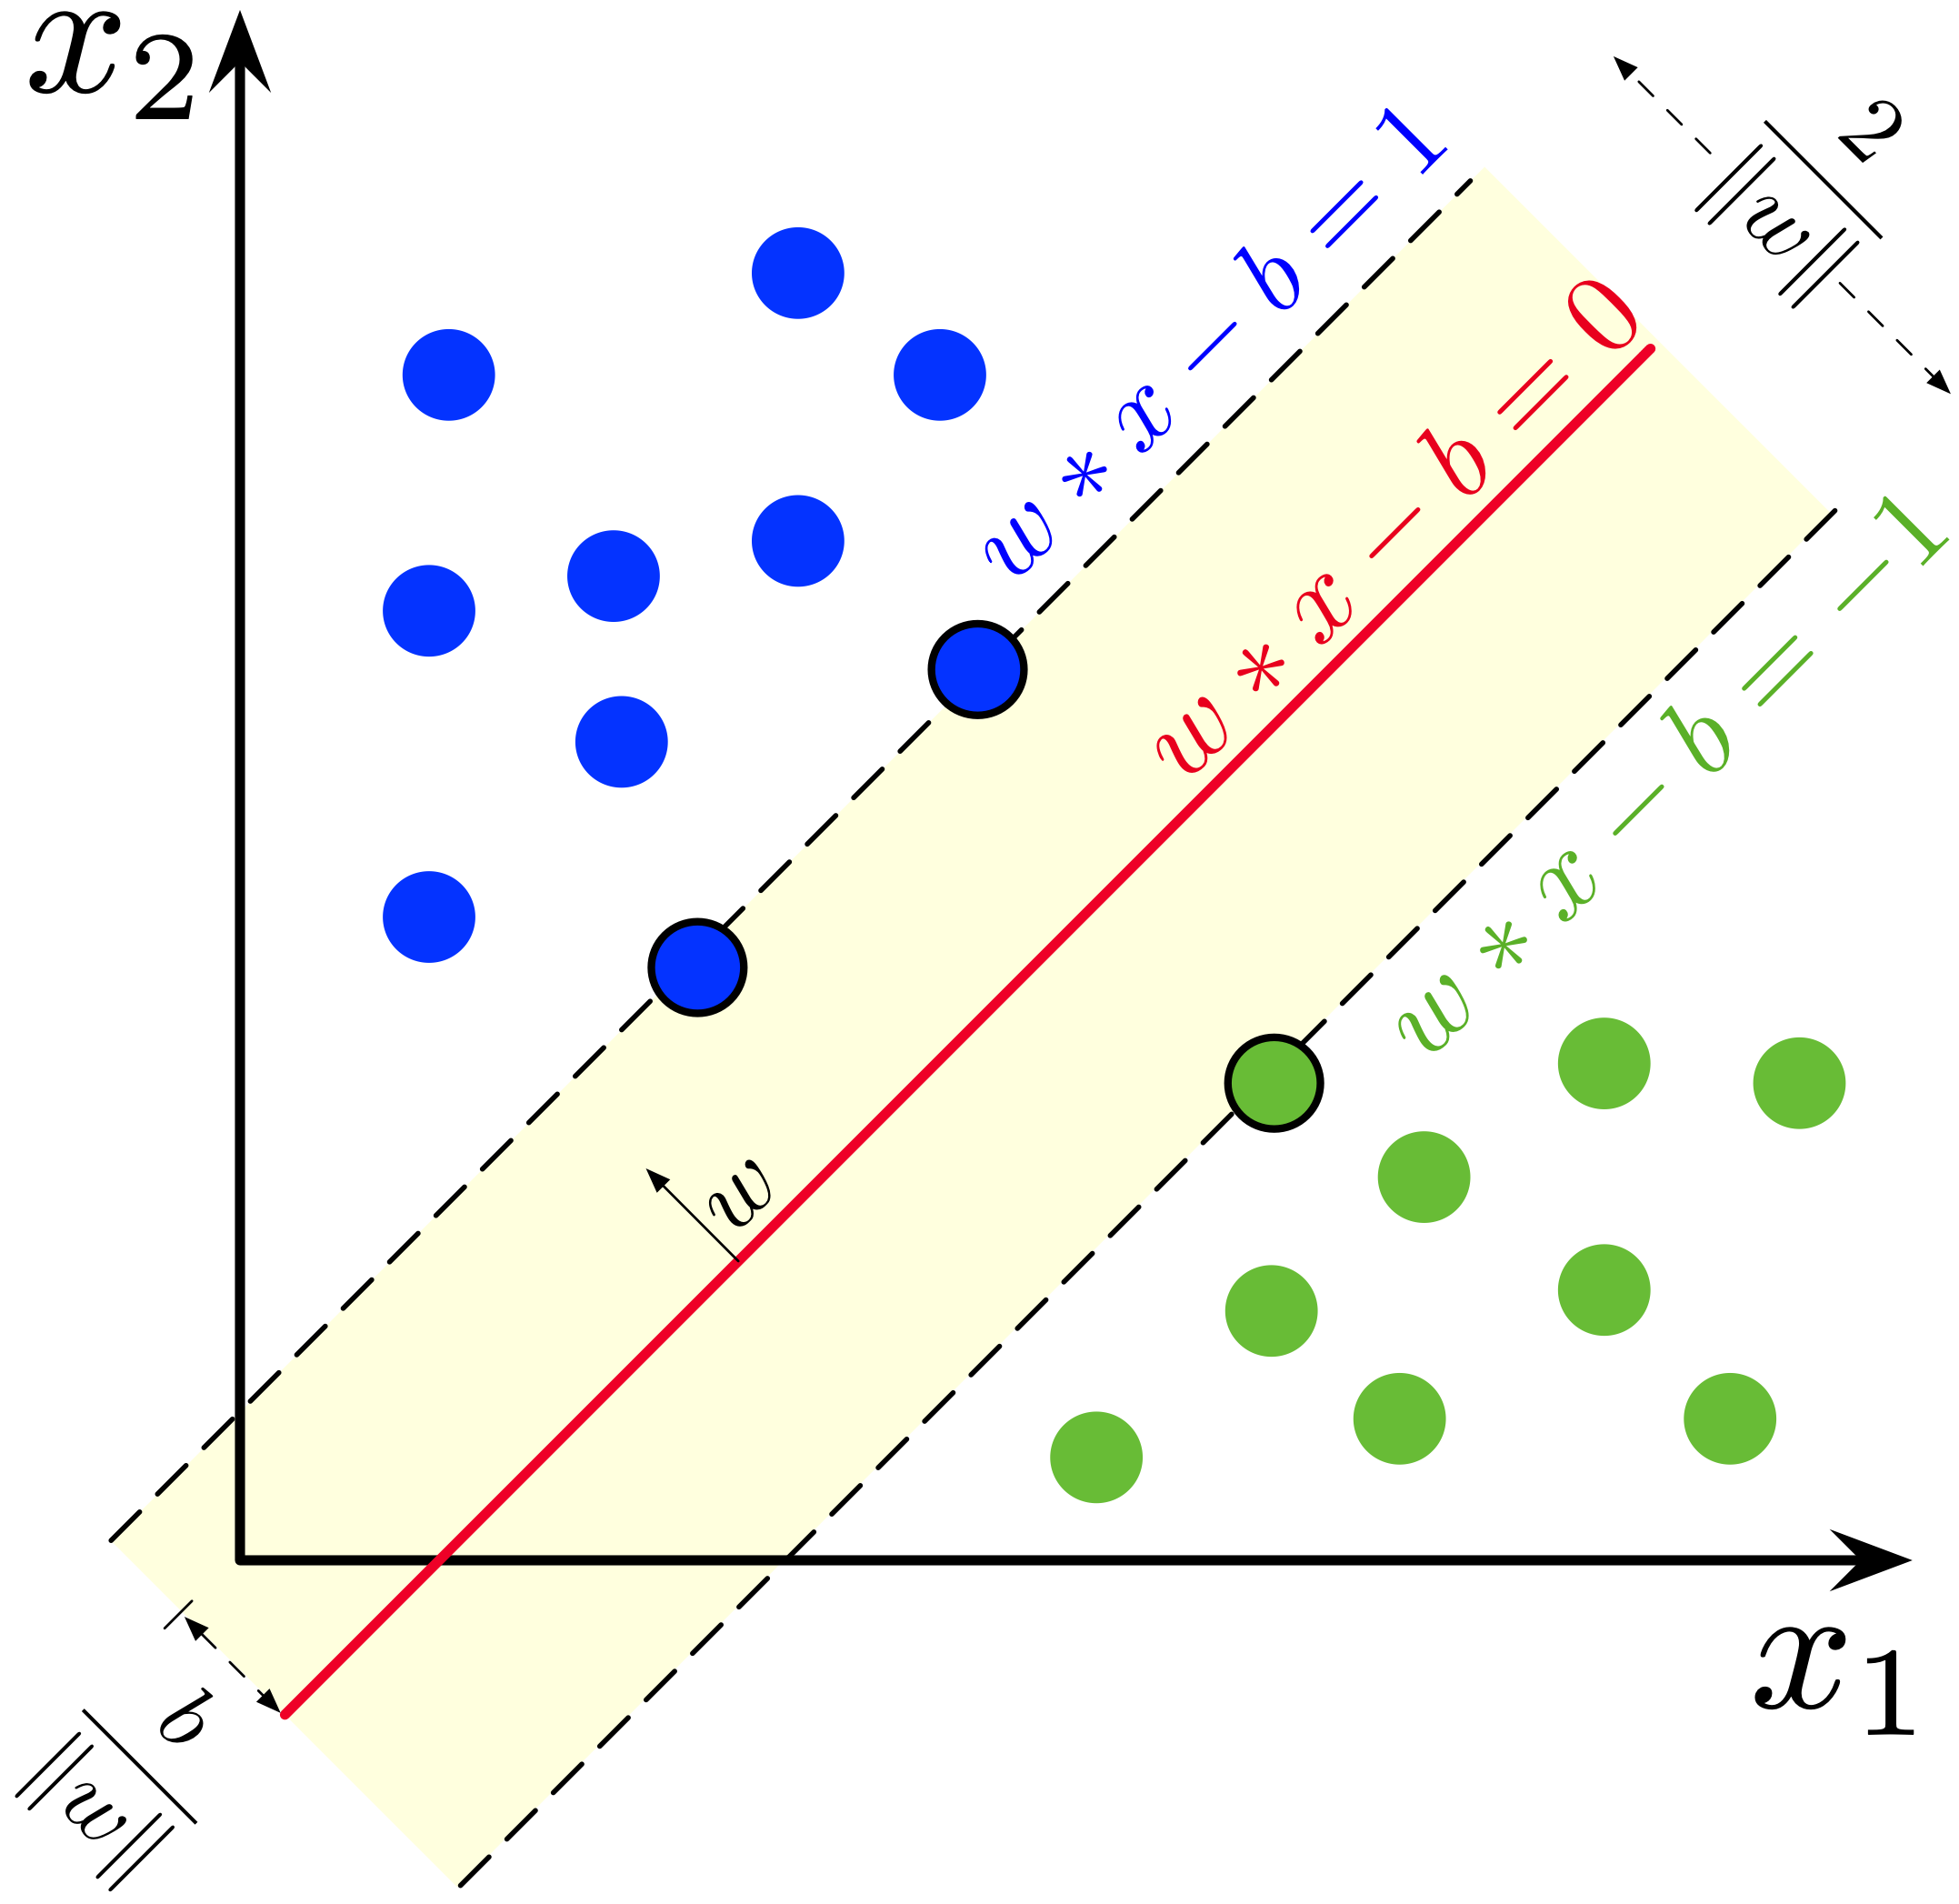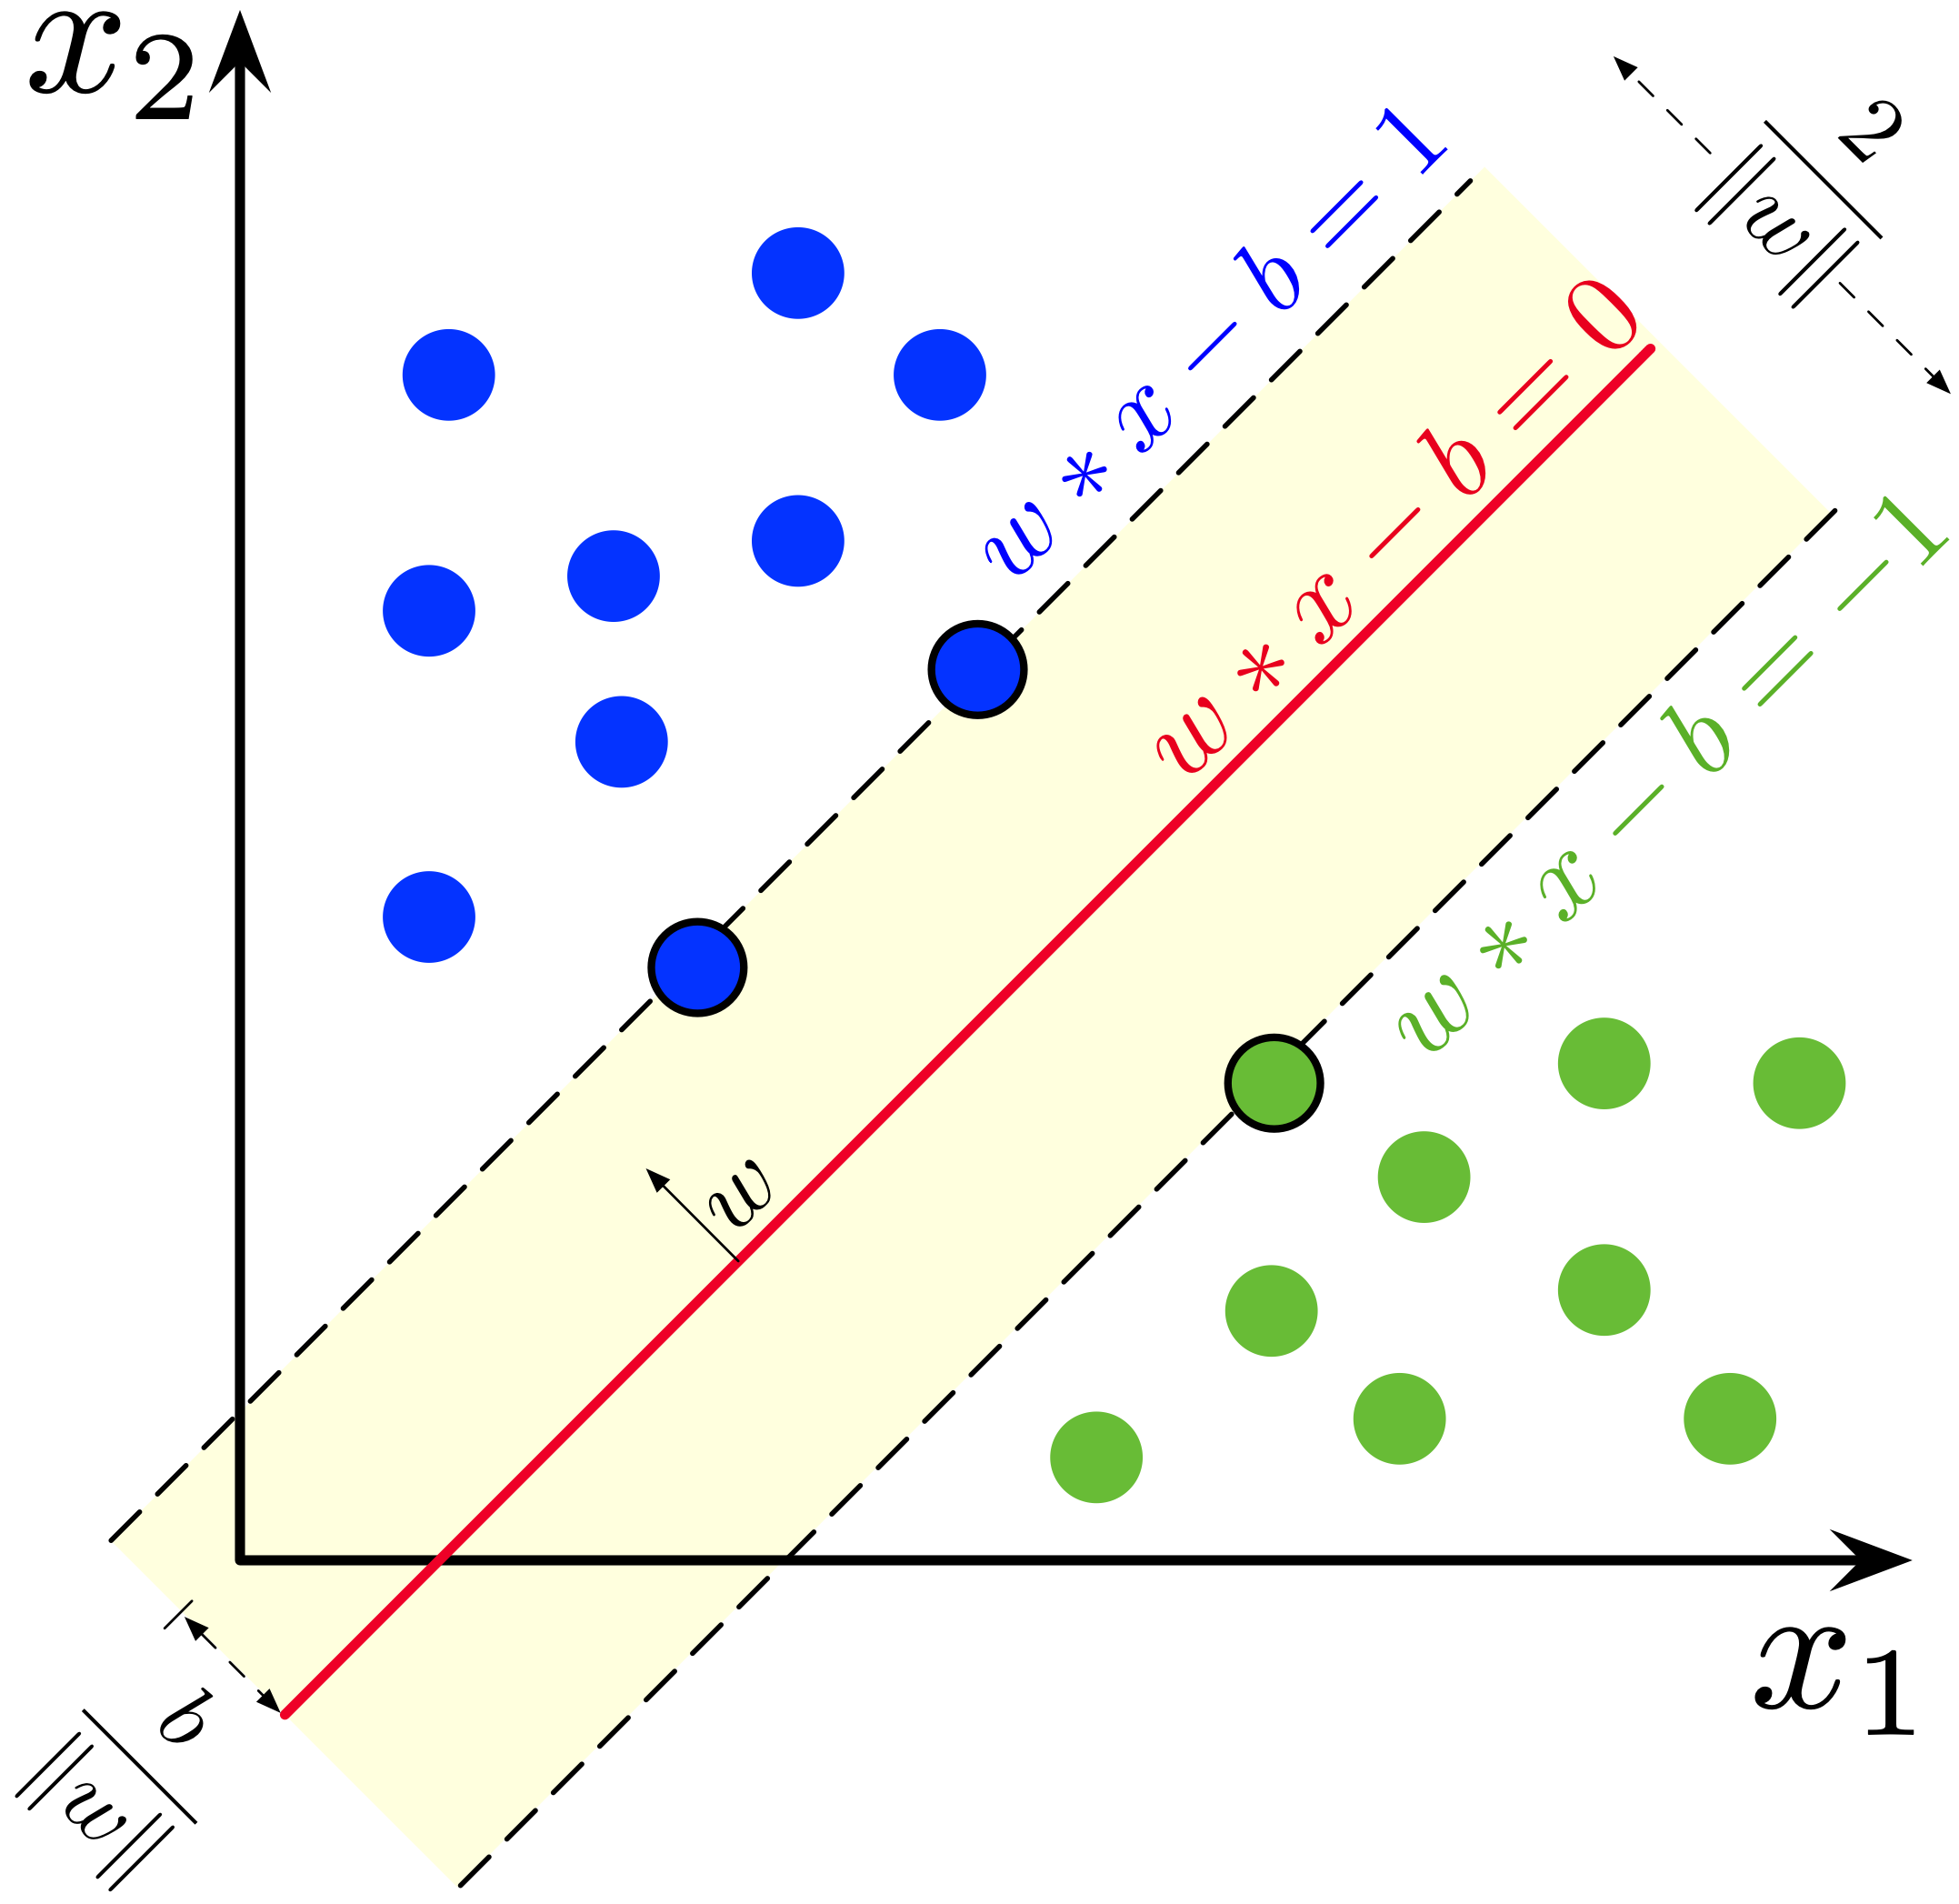

Однако, если мы будем опираться именно на ближайшие к гиперплоскости объекты, то мы будет сверхчувствительны к выбросам. Что нехорошо. Но тем не менее, такой способ называется hard-margin SVM  
Проблема решается с помощью soft margin: мы допускаем некоторые нарушения margin и даже ошибки классификации, но добавляем за них штраф. Параметр C определяет компромисс между максимизацией margin и штрафом за такие нарушения.  
Кстати из-за этой механики для svm рекомендуется использовать скейлер  
Как мы вычисляем штраф? Мы будем использовать кросс-валидацию при подборе soft margin

Однако, что делать, если объекты неразделимы одной простой гиперплоскостью? Тогда, используя kernel functions мы можем перейти в пространство большей размерности, где это возможно, при этом не вычисляя это преобразование явно!  
Это называется kernel trick   
бывают:  
Linear kernel  
Polynomial kernel  
RBF kernel  
Sigmoid kernel  

Параметр gamma используется в SVM с нелинейными ядрами, в частности с RBF kernel. Он определяет, насколько сильно отдельный обучающий объект влияет на окружающее пространство при построении границы классификации.

При маленьком gamma область влияния каждого объекта большая, поэтому граница получается более гладкой. При большом gamma область влияния маленькая, и модель может строить более сложную границу, что повышает риск переобучения.

Таким образом, gamma управляет локальностью модели: маленькие значения дают более глобальную границу, большие — более локальную.

Время писать код!

In [1]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler#на самом деле есть не только стандарт скейлер, нооо лан. Для svm можно ещё использовать MinMaxScaler

Датасет: https://www.kaggle.com/datasets/sayroy1997/madelon

In [2]:
df = pd.read_csv('../datasets/mdlon.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Columns: 501 entries, at1 to T
dtypes: int64(501)
memory usage: 7.6 MB


In [3]:
df.head()

,at1,at2,at3,at4,at5,at6,at7,at8,at9,at10,...,at492,at493,at494,at495,at496,at497,at498,at499,at500,T
0,485,477,537,479,452,471,491,476,475,473,...,481,477,485,511,485,481,479,475,496,-1
1,483,458,460,487,587,475,526,479,485,469,...,478,487,338,513,486,483,492,510,517,-1
2,487,542,499,468,448,471,442,478,480,477,...,481,492,650,506,501,480,489,499,498,-1
3,480,491,510,485,495,472,417,474,502,476,...,480,474,572,454,469,475,482,494,461,1
4,484,502,528,489,466,481,402,478,487,468,...,479,452,435,486,508,481,504,495,511,1


In [4]:
X = df.drop(columns=['T'])
y = df['T']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

Короче, сравнивать будет с логрегом, потому что почему нет

In [5]:
log_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])
log_reg_pipe.fit(X_train, y_train)
y_pred = log_reg_pipe.predict(X_test)
print(f1_score(y_test, y_pred, average='macro'))

0.5337743467838434


In [6]:
linear_svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearSVC())
])
linear_svm_pipe.fit(X_train, y_train)
y_pred = linear_svm_pipe.predict(X_test)
print(f1_score(y_test, y_pred, average='macro'))

0.5376874767342723


In [7]:
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC())
])
svm_pipe.fit(X_train, y_train)
y_pred = svm_pipe.predict(X_test)
print(f1_score(y_test, y_pred, average='macro'))

0.563657907799715


Теперь попробуем подобрать гиперпараметры

In [15]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
}

grid_search = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(grid_search.score(X_test, y_test))
print(grid_search.best_params_, grid_search.best_score_)

0.5459545954595459
{'C': 1} 0.54773320990735


In [9]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [0.01, 0.1, 1, 10, 100],
    "gamma": ["scale", 0.001, 0.01, 0.1, 1]
}

grid_search = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(grid_search.score(X_test, y_test))

KeyboardInterrupt: 

Из-за того что я глупый, грид сёрч у свм затянулся на 3.5 часа. Применю pca и посмотрим. Сравнивать, конечно, не очень хорошо с бейзлайном и прочим, но тем не менее

In [14]:
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
param_grid = {
    "model__kernel": ["linear", "rbf", "poly"],
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.001, 0.01, 0.1, 1]
}
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=20)),#без pca оно работало 11к секунд, клянусь, это недопустимо!
    ('model', SVC())
])
grid_search = GridSearchCV(
    estimator=svm_pipe,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print(grid_search.score(X_test, y_test))
print(grid_search.best_params_)
print(grid_search.best_score_)

0.7539517745478114
{'model__C': 10, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
0.7255855355755679


Ам.. Я хз че писать честн. Я малость сгорел с классик мл и мне хочется покончить с ним как можно раньше. А впереди ещё ноутбука 4, не меньше  
Короче. Мы получили 0.75 ф1 макро с svm после подбора гиперпараметров вместо svm бейзлайнс на 0.56 ф1 макро скора. Мне кажется это круто!